<a href="https://colab.research.google.com/github/melissa-04/arac_visiumhd/blob/main/notebooks/01_data_overview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Block 1 — Mount Drive, define paths, check folders
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path

ROOT = Path('/content/drive/MyDrive/visiumhd')
PATHS = {
    'hd3prime':   ROOT / 'raw' / 'hd3prime_ovarian_ff',
    'probe_deep': ROOT / 'raw' / 'hdprobe_ovarian_ff_deep',
    'probe_min':  ROOT / 'raw' / 'hdprobe_ovarian_ff_min',
    'reference':  ROOT / 'reference',
    'manifests':  ROOT / 'manifests',
    'work':       ROOT / 'work',
    'archive':    ROOT / 'archive_v0',
}
LOCAL = Path('/content/local_data')   # tar files will be extracted here, not on Drive
LOCAL.mkdir(exist_ok=True)

for key, p in PATHS.items():
    status = f'OK  {len(list(p.iterdir())):3d} items' if p.exists() else 'MISSING'
    print(f'{key:11s} {status:15s} {p}')

missing = [k for k, p in PATHS.items() if not p.exists()]
assert not missing, f'Missing folders: {missing}'
print('\nAll folders found.')

Mounted at /content/drive
hd3prime    OK   11 items   /content/drive/MyDrive/visiumhd/raw/hd3prime_ovarian_ff
probe_deep  OK   14 items   /content/drive/MyDrive/visiumhd/raw/hdprobe_ovarian_ff_deep
probe_min   OK    4 items   /content/drive/MyDrive/visiumhd/raw/hdprobe_ovarian_ff_min
reference   OK    2 items   /content/drive/MyDrive/visiumhd/reference
manifests   OK    4 items   /content/drive/MyDrive/visiumhd/manifests
work        OK    1 items   /content/drive/MyDrive/visiumhd/work
archive     OK    4 items   /content/drive/MyDrive/visiumhd/archive_v0

All folders found.


In [ ]:
# Block 2a — Install pinned packages, create step folder
import importlib.util, subprocess, sys
from importlib.metadata import version

if importlib.util.find_spec('anndata') is None:
    r = subprocess.run([sys.executable, '-m', 'pip', 'install', 'anndata==0.13.4', 'pandas==3.0.6'],
                       capture_output=True, text=True, check=True)
    print(r.stdout.strip().splitlines()[-1])   # 'Successfully installed ...'
else:
    print('anndata already installed')

if 'pandas' in sys.modules and sys.modules['pandas'].__version__ != version('pandas'):
    print('RESTART REQUIRED: pandas in memory differs from the installed version')

STEP = '01_data_overview'
WORK = PATHS['work'] / STEP
WORK.mkdir(exist_ok=True)
assert WORK.exists()
print('Step folder:', WORK)

Step folder: /content/drive/MyDrive/visiumhd/work/01_data_overview


In [ ]:
# Block 2b — Record environment: lock file + snapshot + conflict check
import os, platform, psutil, shutil, subprocess, sys
from datetime import date
from importlib.metadata import version

KEY_PKGS = ['numpy', 'pandas', 'scipy', 'h5py', 'anndata', 'pyarrow', 'matplotlib', 'pillow']
lock = ''.join(f'{p}=={version(p)}\n' for p in KEY_PKGS)
freeze = subprocess.run([sys.executable, '-m', 'pip', 'freeze'], capture_output=True, text=True).stdout
conflicts = subprocess.run([sys.executable, '-m', 'pip', 'check'], capture_output=True, text=True).stdout

info = (f'date: {date.today()}\n'
        f'python: {platform.python_version()}\n'
        f'cpu_count: {os.cpu_count()}\n'
        f'ram_total_gb: {psutil.virtual_memory().total / 1e9:.1f}\n'
        f'disk_free_gb: {shutil.disk_usage("/content").free / 1e9:.1f}\n')

tag = f'{STEP}_{date.today()}'
(PATHS['manifests'] / f'requirements_{tag}.txt').write_text(lock)
(PATHS['manifests'] / f'environment_{tag}.txt').write_text(
    info + '\n# pip check\n' + conflicts + '\n# pip freeze\n' + freeze)
assert len(freeze.splitlines()) > 50, 'pip freeze output looks too short'
print(info + '\n' + lock + '\n# pip check\n' + conflicts)

date: 2026-09-30
python: 3.13.15
cpu_count: 8
ram_total_gb: 54.8
disk_free_gb: 220.4

numpy==2.1.3
pandas==3.0.6
scipy==1.16.3
h5py==3.16.0
anndata==0.13.4
pyarrow==23.0.1
matplotlib==3.10.0
pillow==11.3.0

# pip check
ipython 7.34.0 requires jedi, which is not installed.
google-colab 1.0.0 has requirement pandas==2.2.3, but you have pandas 3.0.6.



In [ ]:
# Block 3 — Read the three metrics_summary files and show them side by side
import pandas as pd

DATASETS = ['hd3prime', 'probe_deep', 'probe_min']
metrics = {}
for name in DATASETS:
    files = list(PATHS[name].glob('*metrics_summary.csv'))
    assert len(files) == 1, f'{name}: expected 1 metrics file, found {len(files)}'
    df = pd.read_csv(files[0])
    assert len(df) == 1, f'{name}: expected 1 row, found {len(df)}'
    metrics[name] = df.iloc[0]
    print(f'{name:11s} {len(df.columns):3d} metrics  {files[0].name}')

table = pd.concat(metrics, axis=1)   # rows = metric names, columns = datasets
pd.set_option('display.max_rows', 300, 'display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.0f}' if abs(x) >= 1000 else f'{x:.4g}')
print('\n', table)

hd3prime     46 metrics  Visium_HD_3prime_Human_Ovarian_Cancer_metrics_summary.csv
probe_deep   47 metrics  Visium_HD_Human_Ovarian_Cancer_FF_metrics_summary.csv
probe_min    47 metrics  Visium_HD_Human_Ovarian_Cancer_FF_Min_Depth_metrics_summary.csv

                                                                                  hd3prime                         probe_deep                                    probe_min
Sample ID                                           Visium_HD_3prime_Human_Ovarian_Cancer  Visium_HD_Human_Ovarian_Cancer_FF  Visium_HD_Human_Ovarian_Cancer_FF_Min_Depth
Number of Reads                                                                 558684942                         2316175740                                    441497890
Valid Barcodes                                                                     0.9419                             0.8731                                       0.8726
Valid UMI Sequences                                                

### Blok 3 notları: metrics_summary
Sayılar hep **3' / deep / min** sırasıyla.

**1. Okuma sayısı**
- **Sample ID:** Üç verinin 10x'teki adı; üç dosya da doğru veriye ait.
- **Number of Reads:** Toplam okuma sayısı: 559 milyon / 2,32 milyar / 441 milyon. Deep'te min'in **5,2 katı** okuma var. FASTQ boyutlarına bakıp 9 kat demiştik; o tahmin yanlıştı, dosya boyutu okuma sayısıyla orantılı değilmiş. 3'te min'den %26,5 fazla okuma var.

**2. Okuma kalitesi**
- **Valid Barcodes:** Barkodu slayttaki listeyle eşleşen okumaların oranı: %94 / %87 / %87. 3'te daha yüksek; nedenini bilmiyorum.
- **Valid UMI Sequences:** UMI'si kullanılabilir okumaların oranı; üçünde de %99,8'in üstünde.
- **Q30 (Barcode, UMI, RNA Read / Probe Read):** Yanlış okunma olasılığı en fazla 1/1000 olan harflerin oranı. Hepsi %93–98 arasında; kalite sorunu yok.
- Deep ve min bu oranlarda birebir aynı. Beklediğim gibi, oranlar derinlikten bağımsız.

**3. Hizalama**
- **3':** Okumaların %95'i genoma, %93,1'i güvenle hizalanmış. Güvenle hizalananların dağılımı: %89,8 ekzon, %1,8 intron, %1,4 genler arası bölge. Sayıma giren, transkriptoma güvenle hizalanan okumalar %88,1. Genin ters yönüne düşen (antisense) okumalar %0,8. Okumaların büyük çoğunluğu ekzonlardan geliyor; bu, polyA yakalamayla uyumlu.
- **Prob:** Okumaların %97,6'sı prob setine, %97,5'i güvenle hizalanmış. Sayıma katılan problara (filtered probe set) hizalananlar %96,0. Aradaki ~1,5 puanlık fark, sayıma katılmayan problara düşen okumalar. Eski 01'de raw ile filtered'ın doku içi ortancaları arasında %1,6 fark vardı; büyük olasılıkla nedeni bu.
- **Half-mapped (%0,13) / Split-mapped (%0,02):** Prob çiftinin yalnızca bir yarısı eşleşen ya da iki yarısı farklı genlere düşen okumalar. Önemsiz.
- **Estimated UMIs from Genomic DNA:** UMI'lerin RNA'dan değil genomik DNA'dan gelmiş olabilecek kısmının tahmini: %0,035 / %0,07. Önemsiz. "per Unspliced Probe" satırı (7 / 5) aynı tahminin prob başına hâli; tanımını 10x belgesinden kontrol etmem gerek.

**4. Doygunluk**
- **Sequencing Saturation:** Okumaların daha önce görülmüş bir molekülden gelme oranı: %84,6 / %56,4 / %23,5.
- Deep'te min'in 5,2 katı okuma var ama bin başına UMI yalnızca 3,0 kat fazla (1.810'a karşı 606). Okuma sayısını katlamak molekül sayısını aynı oranda katlamıyor.
- 3'te min'den fazla okuma var ama çok doygun; okumalarının yalnızca ~%15'i yeni bir molekül getiriyor. Yani 3' kütüphanesinde farklı molekül az. Daha fazla dizilemek bu durumu çok az değiştirirdi.

**5. Doku ve ızgara**
- **Number / Fraction of Squares Under Tissue (2 µm):** 7,19 milyon kare (%64,0) / 7,02 milyon kare (%62,6). Buradan toplam kare sayısı 11,22 milyon, yani 3350 × 3350 çıkıyor; ızgaranın bir kenarı 6,7 mm. Doku alanı 3'te 28,7 mm², probda 28,1 mm². Alanların bu kadar yakın olması komşu kesit varsayımıyla uyumlu, ama kanıt değil.
- **Fraction Reads in Squares Under Tissue:** %98,95 / %97,05. Doku dışına düşen okuma payı 3'te %1,05, probda %2,95. İki veride dokunun kapladığı alan benzer olduğu için alan başına karşılaştırma yapabiliyorum: doku dışındaki okuma yoğunluğu, doku içindekinin 3'te ~%2'si, probda ~%5'i. Bu fark kimyadan, dokunun şeklinden ya da maskeden gelebilir; burada karar vermiyorum.
- Bin büyüdükçe doku altı sayılan alan payı biraz artıyor (3'te %64,0 → %64,3 → %64,7). Muhtemelen dokuya kısmen değen kenar bin'leri de doku altı sayılıyor.
- Deep ve min'de bütün kare ve bin sayıları aynı: aynı kesit, aynı doku tespiti.

**6. Bin başına sinyal (ortalamalar)**
- **Mean UMIs per bin:** 2 µm'de 9,8 / 114 / 38; 8 µm'de 156 / 1.810 / 606; 16 µm'de 620 / 7.143 / 2.392.
- **Mean Genes per bin:** 2 µm'de 9,5 / 106 / 37; 8 µm'de 131 / 1.260 / 496; 16 µm'de 439 / 3.401 / 1.576.
- **Mean Reads per bin:** 8 µm'de 1.237 / 5.196 / 991.
- 3'te 8 µm'lik bir bin'de ortalama 156 UMI var. Bu, deep'in ~1/12'si ve min'in ~1/4'ü; üstelik 3'te min'den fazla okuma var. 3' verisi çok daha seyrek.
- 2 µm'lik bir 3' karesinde ~10 UMI ve ~9,5 gen var; yani neredeyse her molekül farklı bir genden geliyor. Tek bir 2 µm karede biyoloji okumak çok zor.
- 8 µm'den 16 µm'ye geçince UMI ~4 kat artıyor, çünkü alan 4 kat büyüyor. Gen sayısı ise daha az artıyor (3'te 3,3 kat), çünkü yeni UMI'lerin bir kısmı zaten görülmüş genlerden.
- Bu metrikler **ortalama**, ortanca değil. 9. blokta kendi hesabımı ortalamayla karşılaştıracağım.
- **UMIs / Reads per sq mm of Tissue:** Aynı yoğunluğun mm² başına hâli (8 µm'lik bir bin 64 µm²). UMI yoğunluğu: 2,4 milyon / 28,3 milyon / 9,5 milyon.

**7. Gen sayısı**
- **Total Genes Detected / Genes Detected:** 26.986 / 17.965 / 17.628.
- **Number of Genes (prob):** Prob setinde sayıma katılan gen sayısı, 18.132. Deep bunların %99'unu görmüş.
- 3' verisi ~9.000 gen daha fazla görüyor. Bu, gen evreni farkı: 3' anotasyondaki bütün genleri ölçebiliyor, prob ise yalnızca prob setindekileri. Ama bin başına bakınca 3' çok daha az gen görüyor.

**8. Hücre metrikleri (segmentasyon)**
- Segmentasyon: Space Ranger H&E görüntüsünden çekirdekleri bulup genişletiyor ve 2 µm kareleri bu hücrelere atıyor. Bu metrikler segmented_outputs'tan geliyor; 01'de kullanmıyorum.
- **Number of Cells:** 200.764 / 183.450 / 183.449.
- **UMIs in Cells:** %91 / %85; UMI'lerin bulunan hücrelerin içine düşen payı.
- **Reads in Cells:** 0,9 / 0,7; yuvarlanmış görünüyor.
- **Median UMIs per Cell:** 258 / 3.277 / 1.097. **Median Genes per Cell:** 218 / 2.129 / 864. **Mean Reads per Cell:** 2.407 / 9.337 / 1.779.
- **Median Cell Area:** 100 / 112 µm². **Median Nucleus Area:** 24 / 28 µm². Ortanca bir hücrenin çapı ~11–12 µm; yani 64 µm²'lik 8 µm bin bir hücreden küçük. Bin ile hücre aynı şey değil.
- **Maximum Nucleus Diameter (256 piksel):** Bir ölçüm değil, segmentasyonun bir ayarı.
- Deep ve min'de hücre sayısı ve alanlar aynı; segmentasyon görüntüden yapıldığı için derinlikten etkilenmiyor.

**Kısaca**
- Deep ile min yalnızca derinlikte farklı: oranlar aynı, UMI sayısı okuma sayısından yavaş artıyor. Öğrendiğim ilkeler tuttu.
- 3', okuma sayısına göre çok az molekül içeriyor ve doygun; bin başına sinyali probdan çok düşük. Bu 02'nin konusu, ama kesit ve donör farkı da işe karışıyor olabilir.
- Doku dışındaki okuma payı probda daha yüksek. Bu, tezin sorusu için ilk ipucu; henüz bir sonuç değil.

In [ ]:
# Block 4 — Save the table, recompute the derived numbers used in the notes
table.to_csv(WORK / 'metrics_summary_side_by_side.csv')
m = table.apply(pd.to_numeric, errors='coerce')   # text rows (Sample ID) -> NaN

def row(text):                                     # find one metric by part of its name
    hits = [name for name in m.index if text in name]
    assert len(hits) == 1, f'{text!r} matched {hits}'
    return m.loc[hits[0]]

reads, umi8 = row('Number of Reads'), row('Mean UMIs Under Tissue per Bin 8')
sq_in, f_area = row('Number of Squares Under Tissue 2'), row('Fraction of Squares Under Tissue 2')
f_reads = row('Fraction Reads in Squares Under Tissue')

derived = pd.DataFrame({
    'reads_vs_min':      reads / reads['probe_min'],
    'umi8_vs_min':       umi8 / umi8['probe_min'],
    'new_molecule_frac': 1 - row('Sequencing Saturation'),
    'grid_side_squares': (sq_in / f_area) ** 0.5,
    'tissue_area_mm2':   sq_in * 4 / 1e6,
    'off_in_density':    ((1 - f_reads) / (1 - f_area)) / (f_reads / f_area),
}).T
derived.to_csv(WORK / 'metrics_derived.csv')
assert derived.notna().all().all(), 'a derived number is missing'
print(derived)

                   hd3prime  probe_deep  probe_min
reads_vs_min          1.265       5.246          1
umi8_vs_min          0.2569       2.986          1
new_molecule_frac    0.1542       0.436     0.7647
grid_side_squares     3,350       3,350      3,350
tissue_area_mm2       28.75        28.1       28.1
off_in_density      0.01882     0.05086    0.05081


### Blok 4 notları: türetilmiş sayılar
Blok 3 notlarındaki el hesaplarımı kodla yeniden yaptım; hepsi tuttu. Sayılar 3' / deep / min sırasıyla.
- **reads_vs_min (1,27 / 5,25 / 1):** Okuma sayısının min'e oranı. Deep'te min'in 5,2 katı, 3'te min'den %27 fazla okuma var.
- **umi8_vs_min (0,26 / 2,99 / 1):** 8 µm'de bin başına ortalama UMI'nin min'e oranı. Deep 5,2 kat okumayla yalnızca 3 kat UMI kazanmış. 3' ise min'den fazla okumaya rağmen min'in ~1/4'ü kadar UMI'ye sahip; okuma başına molekül min'in ~1/5'i.
- **new_molecule_frac (0,15 / 0,44 / 0,76):** Yeni bir molekül getiren okumaların payı (1 − doygunluk). 3' kütüphanesi neredeyse tükenmiş; min'de okumaların çoğu hâlâ yeni molekül getiriyor.
- **grid_side_squares (3.350):** Izgaranın bir kenarı 3.350 kare, yani 6,7 mm. 8 µm'de bir kenarda 838 bin var; 838² = 702.244, eski 01'deki raw bin sayısıyla aynı.
- **tissue_area_mm2 (28,75 / 28,1 / 28,1):** Doku alanı. İki kesit neredeyse aynı büyüklükte ve ızgaranın ~%64'ünü kaplıyor.
- **off_in_density (0,019 / 0,051 / 0,051):** Doku dışındaki okuma yoğunluğunun doku içine oranı. Probda ~%5, 3'te ~%2. Deep ile min aynı, yani derinlikten bağımsız. Bu okuma düzeyinde bir ipucu; UMI düzeyinde 10. blokta tekrar bakacağım.

In [ ]:
# Block 5a — Look inside web_summary.html for version strings (explore, no writing)
import re

for name in ['hd3prime', 'probe_deep']:
    files = list(PATHS[name].glob('*web_summary.html'))
    assert len(files) == 1, f'{name}: expected 1 web_summary, found {len(files)}'
    html = files[0].read_text(errors='ignore')
    pairs = re.findall(r'\["([^"]{2,40})",\s*"([^"]{1,150})"\]', html)   # ["label", "value"]
    keep = [p for p in pairs if re.search(r'Version|Reference|Transcriptome|Probe|Chemistry', p[0])]
    print(f'\n=== {name} ({len(html) / 1e6:.1f} MB, {len(pairs)} label-value pairs) ===')
    for label, value in dict(keep).items():
        print(f'{label:35s} {value}')
    print('spaceranger strings:', sorted(set(re.findall(r'spaceranger-[\d.]+', html))))


=== hd3prime (12.3 MB, 342 label-value pairs) ===
Chemistry                           Visium HD H1 Slide - 3'
Transcriptome                       GRCh38-2024-A
Pipeline Version                    spaceranger-4.0.1
CytAssist Instrument Software Version 2.3.0.6
spaceranger strings: ['spaceranger-4.0.1']

=== probe_deep (19.3 MB, 347 label-value pairs) ===
Chemistry                           Visium HD H1 Slide - HD probe-based v1
Probe Set Name                      Visium Human Transcriptome Probe Set v2.1.0
Transcriptome                       GRCh38-2024-A
Pipeline Version                    spaceranger-4.0.1
Filter Probes                       On
CytAssist Instrument Software Version 2.3.0.6
Reads Mapped to Probe Set           97.6%
Reads Mapped Confidently to Probe Set 97.5%
Reads Half-Mapped to Probe Set      0.1%
Reads Split-Mapped to Probe Set     0.0%
Q30 Bases in Probe Read             97.6%
spaceranger strings: ['spaceranger-4.0.1']


### Blok 5a notları: sürümler (web_summary)
- İki web_summary dosyasında da etiket–değer çiftlerini bulabildim (342 ve 347 çift).
- **Space Ranger:** 3' ve deep'te **4.0.1**. 3' için yazdığım beklenti ve eski 01'deki deep bilgisi tuttu.
- **Referans (Transcriptome):** İkisinde de **GRCh38-2024-A**; 10x'in GRCh38 genomu ve 2024 anotasyonuyla hazırladığı insan referansı. Prob verisinde de prob setinin yanında bu transkriptom referansı kullanılmış.
- **Prob seti:** Visium Human Transcriptome Probe Set **v2.1.0**. **Filter Probes: On**, yani sayıma katılmayan (included = FALSE) problar filtered matriste yok. Blok 3'teki ~1,5 puanlık fark bununla uyumlu.
- **Chemistry:** İkisi de "Visium HD H1 Slide"; biri 3', öteki prob tabanlı.
- **CytAssist yazılımı:** İkisinde de 2.3.0.6.
- Listedeki "Reads Mapped to Probe Set" gibi satırlar, filtremde "Probe" geçtiği için yakalanan metrikler; metrics_summary'deki değerlerle aynı.
- **Sonuç:** 3' ile prob arasında program, referans ve CytAssist yazılımı aynı. Blok 3–4'teki farkları bunlar açıklayamaz; geriye kimya, kesit/donör, kütüphane hazırlığı ve derinlik kalıyor.
- **Açık iki nokta:**
  - min'in web_summary dosyası olmadığı için sürümü doğrulanmadı.
  - GRCh38-2024-A'nın hangi GENCODE sürümüne dayandığını kontrol etmem gerek; bizim reference/ klasörümüzdeki GTF v46.

In [ ]:
# Block 5b — Add software/reference versions to the data manifest (one-time backup first)
import shutil
from datetime import date

mf = PATHS['manifests'] / 'data_manifest.csv'
man = pd.read_csv(mf)
folder = man['drive_path'].str.extract(r'raw/([^/]+)/')[0]   # dataset folder of each file

VERSIONS = {  # folder: (spaceranger_version, transcriptome, probe_set, version_source)
    'hd3prime_ovarian_ff':     ('spaceranger-4.0.1', 'GRCh38-2024-A', None, 'web_summary'),
    'hdprobe_ovarian_ff_deep': ('spaceranger-4.0.1', 'GRCh38-2024-A',
                                'Visium Human Transcriptome Probe Set v2.1.0', 'web_summary'),
    'hdprobe_ovarian_ff_min':  (None, None, None, 'not verified (no web_summary)'),
}
assert folder.isin(list(VERSIONS)).all(), 'some manifest rows have no known dataset folder'

backup = PATHS['manifests'] / f'data_manifest_before_01_{date.today()}.csv'
if not backup.exists():                      # keep the original even if this block is re-run
    shutil.copy(mf, backup)

cols = ['spaceranger_version', 'transcriptome', 'probe_set', 'version_source']
man[cols] = pd.DataFrame([VERSIONS[f] for f in folder], index=man.index, columns=cols)
man.to_csv(mf, index=False)
assert set(cols) <= set(pd.read_csv(mf).columns)
print(folder.value_counts(), '\n\n', man.groupby(folder)[cols].first())

0
hdprobe_ovarian_ff_deep    13
hd3prime_ovarian_ff        10
hdprobe_ovarian_ff_min      4
Name: count, dtype: int64 

                         spaceranger_version  transcriptome                                    probe_set                 version_source
0                                                                                                                                     
hd3prime_ovarian_ff       spaceranger-4.0.1  GRCh38-2024-A                                          NaN                    web_summary
hdprobe_ovarian_ff_deep   spaceranger-4.0.1  GRCh38-2024-A  Visium Human Transcriptome Probe Set v2.1.0                    web_summary
hdprobe_ovarian_ff_min                  NaN            NaN                                          NaN  not verified (no web_summary)


### Blok 5b notları: manifeste sürümler
- Manifestin orijinal hâlini data_manifest_before_01_2026-09-29.csv olarak bir kez yedekledim.
- Manifeste dört sütun ekledim: spaceranger_version, transcriptome, probe_set, version_source.
- Satırları drive_path'teki klasör adından verilere eşledim: deep 13, 3' 10, min 4, toplam 27. Bu sayılar 00'dakilerle aynı.
- 3' ve deep: spaceranger-4.0.1 ve GRCh38-2024-A; deep'te ayrıca prob seti v2.1.0. 3'ün probe_set alanı boş, çünkü 3' kimyası prob kullanmıyor.
- min: web_summary indirilmediği için sürüm alanları boş ve "not verified" notlu.
- Çıktıdaki "0" başlığı, klasör sütununun otomatik adı; sonuca etkisi yok.
- Böylece 00'dan kalan eksik (sürüm bilgisi) kapandı.

In [ ]:
# Block 6a — Extract 3' square_008um + spatial.tar.gz to local disk (timed)
import time, subprocess

binned = list(PATHS['hd3prime'].glob('*binned_outputs.tar.gz'))
spatial = list(PATHS['hd3prime'].glob('*spatial.tar.gz'))
assert len(binned) == 1 and len(spatial) == 1, (binned, spatial)
print(f'binned_outputs: {binned[0].stat().st_size / 1e9:.1f} GB | spatial: {spatial[0].stat().st_size / 1e9:.2f} GB')

DEST = LOCAL / 'hd3prime'
DEST.mkdir(exist_ok=True)
t0 = time.time()
r = subprocess.run(['tar', '-xzf', binned[0], '-C', DEST, '--wildcards', '*square_008um*'],
                   capture_output=True, text=True)
subprocess.run(['tar', '-xzf', spatial[0], '-C', DEST], check=True)
print(f'done in {(time.time() - t0) / 60:.1f} min | tar exit code: {r.returncode}')
print('tar messages:', r.stderr.strip().splitlines()[:5])
print(sorted(p.name for p in DEST.iterdir()))

binned_outputs: 11.3 GB | spatial: 0.07 GB
done in 3.5 min | tar exit code: 2
tar messages: ['tar: binned_outputs/square_008um/spatial/aligned_fiducials.jpg: Cannot hard link to ‘binned_outputs/square_002um/spatial/aligned_fiducials.jpg’: No such file or directory', 'tar: binned_outputs/square_008um/spatial/aligned_tissue_image.jpg: Cannot hard link to ‘binned_outputs/square_002um/spatial/aligned_tissue_image.jpg’: No such file or directory', 'tar: binned_outputs/square_008um/spatial/cytassist_image.tiff: Cannot hard link to ‘binned_outputs/square_002um/spatial/cytassist_image.tiff’: No such file or directory', 'tar: binned_outputs/square_008um/spatial/detected_tissue_image.jpg: Cannot hard link to ‘binned_outputs/square_002um/spatial/detected_tissue_image.jpg’: No such file or directory', 'tar: binned_outputs/square_008um/spatial/tissue_hires_image.png: Cannot hard link to ‘binned_outputs/square_002um/spatial/tissue_hires_image.png’: No such file or directory']
['binned_outputs', 'spa

### Blok 6a notları: arşivleri açma
- 3' binned_outputs arşivi 11,3 GB, spatial arşivi 0,07 GB.
- Yalnızca square_008um'u açtım, ama tar yine de 11,3 GB'ın tamamını okudu: 3,5 dakika, saniyede ~54 MB. Bu, 00'da ölçtüğüm Drive okuma hızıyla uyumlu.
- tar çıkış kodu 2 verdi. Gördüğüm beş mesajın hepsi "Cannot hard link" uyarısıydı: square_008um/spatial'daki görüntüler, açmadığım 2 µm klasöründeki dosyaların ikinci adlarıymış. Beklediğim bir durum.
- Yalnızca ilk beş mesajı yazdırdım. Bütün mesajları ve eksik görüntüleri 6b'de kontrol edip spatial.tar.gz'den tamamlayacağım.

In [ ]:
# Block 6b — Check all tar messages, restore missing images, list the 8 µm folder
import re, shutil

msgs = r.stderr.strip().splitlines()
links = [m for m in msgs if 'Cannot hard link' in m]
others = [m for m in msgs if m not in links and 'Exiting with failure' not in m]
assert not others, f'unexpected tar messages: {others}'

missing = [re.search(r'tar: (\S+): Cannot hard link', m).group(1) for m in links]
assert all('/square_008um/spatial/' in p for p in missing), missing
for p in missing:
    shutil.copy2(DEST / 'spatial' / Path(p).name, DEST / p)
print(f'{len(msgs)} tar messages, {len(links)} hard links restored:', [Path(p).name for p in missing])

S8 = DEST / 'binned_outputs' / 'square_008um'
files = [p for p in sorted(S8.rglob('*')) if p.is_file()]
for p in files:
    if 'analysis' not in p.parts:
        print(f'{p.stat().st_size / 1e6:9.1f} MB  {p.relative_to(S8)}')
print('analysis/ files:', sum('analysis' in p.parts for p in files))

7 tar messages, 6 hard links restored: ['aligned_fiducials.jpg', 'aligned_tissue_image.jpg', 'cytassist_image.tiff', 'detected_tissue_image.jpg', 'tissue_hires_image.png', 'tissue_lowres_image.png']
   8649.6 MB  cloupe.cloupe
      2.3 MB  filtered_feature_bc_matrix/barcodes.tsv.gz
      0.3 MB  filtered_feature_bc_matrix/features.tsv.gz
    244.8 MB  filtered_feature_bc_matrix/matrix.mtx.gz
     99.4 MB  filtered_feature_bc_matrix.h5
      1.9 MB  raw_feature_bc_matrix/barcodes.tsv.gz
      0.3 MB  raw_feature_bc_matrix/features.tsv.gz
    247.4 MB  raw_feature_bc_matrix/matrix.mtx.gz
    106.6 MB  raw_feature_bc_matrix.h5
      2.8 MB  spatial/aligned_fiducials.jpg
      1.9 MB  spatial/aligned_tissue_image.jpg
     25.0 MB  spatial/cytassist_image.tiff
      1.5 MB  spatial/detected_tissue_image.jpg
      0.0 MB  spatial/scalefactors_json.json
     38.5 MB  spatial/tissue_hires_image.png
      0.3 MB  spatial/tissue_lowres_image.png
     11.3 MB  spatial/tissue_positions.parquet
an

### Blok 6b notları: açılan 8 µm klasörü
- tar 7 mesaj vermiş: 6'sı hard link uyarısı, 1'i bunların özeti ("Exiting with failure"). Başka hata yok.
- Eksik 6 görüntüyü (6a'da görünen 5'i ve tissue_lowres_image.png) spatial.tar.gz'den tamamladım. Bu görüntülerin 2 µm klasöründekilerle aynı olduğunu varsayıyorum, çünkü hepsi aynı Space Ranger çalışmasından geliyor.
- **cloupe.cloupe (8,6 GB):** Loupe Browser için hazırlanmış dosya; arşivin çoğunu bu kaplıyor. Analizde kullanmıyorum.
- **Matrisler iki biçimde var:** .h5 ve metin tabanlı MEX klasörü (barcodes, features, matrix.mtx.gz). İçerikleri aynı ama .h5 daha küçük (filtered için 99 MB'a karşı 245 MB). .h5'i kullanacağım.
- **raw .h5 filtered'dan yalnızca %7 büyük** (107 MB'a karşı 99 MB). Oysa raw'da muhtemelen ~%55 daha fazla bin var (ızgaranın tamamı ~702 bin, doku altı 451 bin). Doku dışındaki bin'ler çok az sayım taşıdığı için seyrek dosyaya az yük ekliyor. Bin sayısını 7. blokta doğrulayacağım.
- **spatial/:**
  - tissue_positions.parquet: bin koordinatları ve in_tissue,
  - scalefactors_json.json: ölçek katsayıları,
  - tissue_hires/lowres: küçültülmüş H&E,
  - detected_tissue_image.jpg: Space Ranger'ın doku tespiti,
  - aligned_fiducials.jpg: hizalama işaretleri,
  - cytassist_image.tiff: CytAssist'in çektiği görüntü.
- **analysis/ (26 dosya):** Space Ranger'ın kendi kümeleme, PCA ve UMAP sonuçları; 01'de kullanmıyorum.

In [ ]:
# Block 7a — Read the 8 µm filtered and raw matrices (10x HDF5) into AnnData with h5py
import h5py, scipy.sparse as sp, anndata as ad

def read_10x_h5(path):
    """10x HDF5 (genes x bins, CSC) -> AnnData (bins x genes); genes indexed by Ensembl ID."""
    with h5py.File(path, 'r') as f:
        m = f['matrix']
        X = sp.csc_matrix((m['data'][:], m['indices'][:], m['indptr'][:]), shape=tuple(m['shape'][:]))
        var = pd.DataFrame({'symbol': m['features/name'][:].astype(str),
                            'feature_type': m['features/feature_type'][:].astype(str)},
                           index=m['features/id'][:].astype(str))
        obs = pd.DataFrame(index=m['barcodes'][:].astype(str))
    return ad.AnnData(X=X.T.tocsr(), obs=obs, var=var)

S8 = DEST / 'binned_outputs' / 'square_008um'
filt = read_10x_h5(S8 / 'filtered_feature_bc_matrix.h5')
raw = read_10x_h5(S8 / 'raw_feature_bc_matrix.h5')
for name, a in [('filtered', filt), ('raw', raw)]:
    print(f'{name:8s} {a.n_obs:>8,} bins x {a.n_vars:,} genes | '
          f'nonzero {a.X.nnz:,} ({a.X.nnz / (a.n_obs * a.n_vars):.3%}) | UMIs {int(a.X.sum()):,}')

filtered  451,466 bins x 38,606 genes | nonzero 59,279,712 (0.340%) | UMIs 70,319,988
raw       702,244 bins x 38,606 genes | nonzero 60,071,857 (0.222%) | UMIs 71,131,152


### Blok 7a notları: matrisleri yükleme
- 8 µm filtered ve raw .h5 dosyalarını kendi fonksiyonumla (h5py) okuyup AnnData'ya aldım. Genler Ensembl kimliğiyle adlandırıldı, sembol ayrı bir sütunda.
- **Bin sayısı:** filtered'da 451.466 (metrics_summary ile aynı), raw'da 702.244 = 838 × 838, yani ızgaranın tamamı.
- **Gen sayısı:** İkisinde de 38.606; bu, GRCh38-2024-A referansındaki gen sayısı. Dokuda görülen 26.986; yani referans genlerinin ~11.600'ü (%30) hiç görülmemiş.
- **Sıfır olmayan hücreler:** filtered'da 59,3 milyon; bin başına 131,3. Bu, metrics_summary'deki "Mean Genes per Bin 8 µm" değeriyle birebir aynı. Bir bin 38.606 genin yalnızca %0,34'ünü görüyor.
- **UMI:** filtered'da 70,3 milyon; bin başına 155,8, metrics_summary ile aynı. Okuma fonksiyonum doğru çalışıyor.
- **Doku dışı (raw − filtered):** 250.778 bin'de 811 bin UMI; toplam UMI'nin %1,14'ü. Doku dışında bin başına 3,2 UMI, doku içinde 155,8; alan başına ~%2,1. Okumalardan bulduğum ~%1,9'a yakın. Doku dışında neredeyse her UMI farklı bir genden geliyor. (filtered'ın raw'ın doku içi kısmı olduğunu 7b'de doğrulayacağım.)

In [ ]:
# Block 7b — Consistency checks: filtered vs raw (8 µm)
assert filt.obs_names.isin(raw.obs_names).all(), 'some filtered bins are missing from raw'
shared = raw[filt.obs_names]                     # raw rows for the filtered bins, same order

checks = {
    'same genes, same order':        bool(filt.var_names.equals(raw.var_names)),
    'same gene symbols':             bool(filt.var['symbol'].equals(raw.var['symbol'])),
    'identical counts (shared bins)': (shared.X != filt.X).nnz == 0,
    'only Gene Expression features': set(raw.var['feature_type']) == {'Gene Expression'},
}
for k, v in checks.items():
    print(f'{k:32s} {v}')
assert all(checks.values()), 'a consistency check failed'
print(f'\noff-tissue bins (raw only): {raw.n_obs - filt.n_obs:,}')

same genes, same order           True
same gene symbols                True
identical counts (shared bins)   True
only Gene Expression features    True

off-tissue bins (raw only): 250,778


### Blok 7b notları: filtered ile raw tutarlı mı?
- filtered'daki her bin raw'da da var. Gen listesi (sıra dahil) ve semboller aynı, ortak bin'lerde sayımlar birebir aynı, bütün özellikler gen ifadesi.
- Yani 3'te raw = filtered + 250.778 doku dışı bin. Prob verisinde raw'a sayıma katılmayan problardan gelen sayımlar da ekleniyordu; 3'te böyle bir fark yok.
- Böylece 7a'daki doku dışı sayıların (811 bin UMI, toplamın %1,14'ü, bin başına 3,2 UMI) gerçekten doku dışındaki bin'lere ait olduğu doğrulandı.
- Bundan sonra raw'ı tek matris olarak kullanıp doku içini seçebilirim; filtered'ı ayrıca tutmam gerekmiyor.

In [ ]:
# Block 8a — Add bin coordinates and in_tissue (tissue_positions.parquet) to raw
pos = pd.read_parquet(S8 / 'spatial' / 'tissue_positions.parquet').set_index('barcode')
print(pos.columns.tolist(), pos.shape)
assert pos.index.is_unique and set(pos.index) == set(raw.obs_names), 'positions do not match raw bins'

raw.obs = raw.obs.join(pos)
in_t = raw.obs['in_tissue'] == 1
assert set(raw.obs_names[in_t]) == set(filt.obs_names), 'in_tissue=1 bins differ from filtered bins'

n_rows, n_cols = raw.obs['array_row'].nunique(), raw.obs['array_col'].nunique()
assert n_rows * n_cols == raw.n_obs, 'grid is not complete'
print(f'grid: {n_rows} x {n_cols} = {n_rows * n_cols:,} bins | in_tissue=1: {in_t.sum():,}')
print(raw.obs.head(3))

['in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres'] (702244, 5)
grid: 838 x 838 = 702,244 bins | in_tissue=1: 451,466
                       in_tissue  array_row  array_col  pxl_row_in_fullres  pxl_col_in_fullres
s_008um_00000_00000-1          0          0          0              30,114               1,199
s_008um_00000_00001-1          0          0          1              30,114               1,229
s_008um_00000_00002-1          0          0          2              30,114               1,258


### Blok 8a notları: koordinatlar ve doku işareti
- tissue_positions.parquet'te 702.244 bin ve 5 sütun var: in_tissue, array_row, array_col, pxl_row_in_fullres, pxl_col_in_fullres. Bin'ler raw'dakilerle birebir aynı.
- Izgara 838 × 838 ve eksiksiz. in_tissue = 1 olan 451.466 bin, filtered'daki bin'lerle birebir aynı; yani filtered matris Space Ranger'ın doku tespitinin ta kendisi.
- Barkodun kendisi konumu söylüyor: s_008um_00000_00001-1 = kare (s), 8 µm, satır 0, sütun 1. Sondaki -1 kütüphane numarası.
- Yan yana iki bin arasında piksel sütunu ~29,5 artıyor; 8 µm ÷ 29,5 ≈ 0,27 µm/piksel. Tam çözünürlüklü H&E'de bir piksel ~0,27 µm. 8b'de scalefactors'daki değerle doğrulayacağım.
- Izgaranın 0. satırı görüntüde 30.114. piksel satırında; ızgaranın yönü görüntünün yönüyle aynı olmak zorunda değil. Haritada her zaman pxl_* sütunlarını kullanacağım.
- Piksel değerleri aslında ondalıklı; Blok 3'teki görüntüleme ayarı yüzünden yuvarlanmış görünüyor.

In [ ]:
# Block 8b — Scale factors, µm per pixel, tissue area and coverage (8 µm bins)
import json, numpy as np

sf = json.loads((S8 / 'spatial' / 'scalefactors_json.json').read_text())
raw.uns['scalefactors'] = sf
print(json.dumps(sf, indent=1))

o = raw.obs.sort_values(['array_row', 'array_col'])
g = o.groupby('array_row')
step_px = np.hypot(g['pxl_row_in_fullres'].diff(), g['pxl_col_in_fullres'].diff()).median()
print(f'\nmeasured from coordinates: {step_px:.2f} px per bin -> {sf["bin_size_um"] / step_px:.4f} µm/pixel')

area = lambda n: n * sf['bin_size_um'] ** 2 / 1e6          # number of 8 µm bins -> mm²
print(f'tissue: {area(in_t.sum()):.2f} mm² | grid: {area(raw.n_obs):.2f} mm² | coverage: {in_t.mean():.2%}')
assert sf['bin_size_um'] == 8

{
 "spot_diameter_fullres": 29.228423421146363,
 "bin_size_um": 8.0,
 "microns_per_pixel": 0.2737061758251425,
 "tissue_lowres_scalef": 0.0071874363,
 "fiducial_diameter_fullres": 1205.6724661222877,
 "tissue_hires_scalef": 0.071874365,
 "regist_target_img_scalef": 0.071874365
}

measured from coordinates: 29.23 px per bin -> 0.2737 µm/pixel
tissue: 28.89 mm² | grid: 44.94 mm² | coverage: 64.29%


### Blok 8b notları: ölçek ve alan
- **microns_per_pixel = 0,2737:** Tam çözünürlüklü H&E'de bir piksel 0,274 µm. Koordinatlardan kendim ölçtüğüm değer de 0,2737 (bir 8 µm bin = 29,23 piksel); ölçek bilgisi ile koordinatlar tutarlı.
- **hires ölçeği 0,0719:** Bir hires pikseli ≈ 3,8 µm, yani bir bin ≈ 2 piksel. Haritalar için yeterli.
- **lowres ölçeği 0,00719:** Bir lowres pikseli ≈ 38 µm, yani ~5 bin. Yalnızca genel görünüm için.
- Hizalamada kullanılan görüntünün ölçeği hires ile aynı. Hizalama işaretlerinin çapı ≈ 330 µm.
- **Doku alanı 28,89 mm², ızgara 44,94 mm² (6,7 × 6,7 mm), kaplama %64,29;** metrics_summary ile aynı. 2 µm karelerden bulduğum 28,75 mm²'den %0,5 büyük, çünkü 8 µm'de dokuya kısmen değen kenar bin'leri de doku sayılıyor.

In [ ]:
# Block 9a — Per-bin QC metrics (UMI, genes, % mitochondrial); summary for in-tissue bins
import numpy as np, pandas as pd

X = raw.X.tocsr()
raw.obs['umi'] = np.asarray(X.sum(axis=1)).ravel()
raw.obs['genes'] = np.diff(X.indptr)                  # stored (non-zero) genes per bin
mt = raw.var['symbol'].str.startswith('MT-').to_numpy()
raw.obs['pct_mt'] = 100 * np.asarray(X[:, mt].sum(axis=1)).ravel() / np.maximum(raw.obs['umi'], 1)
print('MT genes:', int(mt.sum()), list(raw.var.loc[mt, 'symbol']))

tis = raw.obs.loc[in_t, ['umi', 'genes', 'pct_mt']]
summary = tis.describe(percentiles=[.05, .25, .5, .75, .95]).T
print(summary)
assert np.isclose(tis['umi'].mean(), row('Mean UMIs Under Tissue per Bin 8')['hd3prime'], rtol=1e-3)
assert np.isclose(tis['genes'].mean(), row('Mean Genes Under Tissue per Bin 8')['hd3prime'], rtol=1e-3)

summary.to_csv(WORK / 'qc_in_tissue_8um.csv')
raw.obs.to_parquet(WORK / 'bins_8um_obs.parquet')

MT genes: 13 ['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB']
         count  mean   std  min  5%  25%   50%   75%   95%   max
umi    451,466 155.8 130.5    0   8   46   132   230   401 1,773
genes  451,466 131.3 100.7    0   8   44   117   196   317 1,040
pct_mt 451,466  2.14 3.172    0   0    0 1.389 2.857 6.931   100


### Blok 9a notları: bin başına QC (doku içi, 8 µm)
- İlk denemede NameError aldım: np tanımlı değildi, çünkü numpy'yi içe aktaran 8b'yi çalıştırmamıştım. Ders: her blok kullandığı paketleri kendisi içe aktarmalı.
- **MT genleri:** 13 tane; mitokondri DNA'sının kodladığı protein genlerinin hepsi (ND1–ND6, ND4L, CYB, CO1–CO3, ATP6, ATP8). Eski prob verisinde 12'ydi.
- **UMI (bin başına):** ortanca 132, ortalama 155,8; %5'lik dilimde 8, %95'lik dilimde 401, en büyük 1.773. Dağılım sağa çarpık. Ortalama metrics_summary ile aynı (assert geçti).
- **Gen (bin başına):** ortanca 117, ortalama 131,3. Düşük uçta gen ≈ UMI; az UMI'li bin'de hemen her UMI farklı bir genden. Yüksek uçta gen sayısı geride kalıyor.
- **Sıfır UMI'li doku içi bin'ler var** (en küçük değer 0). Boşluk mu, doku tespiti hatası mı; haritada bakacağım.
- **%MT:** ortanca %1,39, %95'lik dilimde %6,9. Bin'lerin en az %25'inde hiç MT UMI'si yok, bazı bin'lerde %100. Az sayımda %MT çok gürültülü. Eski prob verisindeki %7 ile doğrudan kıyaslanamaz (gen evreni farklı). %MT'yi filtre olarak kullanmayacağım.
- Özet tabloyu qc_in_tissue_8um.csv, bin başına tabloyu bins_8um_obs.parquet olarak work/'e kaydettim.

in-tissue bins with 0 UMI: 480 | with <10 UMI: 29,863 (6.6%)


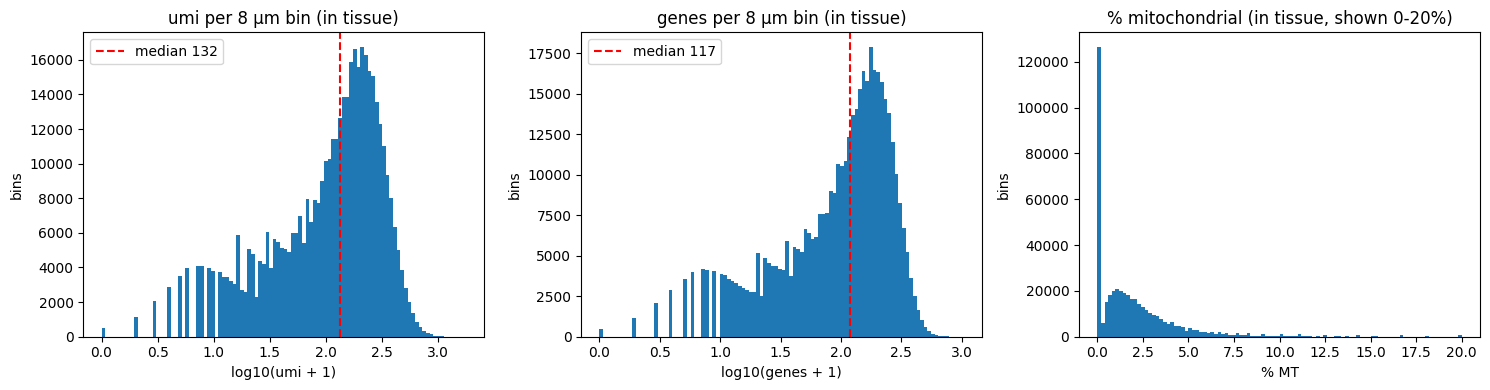

In [ ]:
# Block 9b — Histograms of per-bin QC (in-tissue bins) + count of empty / very low bins
import numpy as np, matplotlib.pyplot as plt

tis = raw.obs.loc[in_t, ['umi', 'genes', 'pct_mt']]
low = tis['umi'] < 10
print(f"in-tissue bins with 0 UMI: {(tis['umi'] == 0).sum():,} | with <10 UMI: {low.sum():,} ({low.mean():.1%})")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax[:2], ['umi', 'genes']):
    a.hist(np.log10(tis[col] + 1), bins=100)
    a.axvline(np.log10(tis[col].median() + 1), color='red', ls='--', label=f'median {tis[col].median():.0f}')
    a.set(title=f'{col} per 8 µm bin (in tissue)', xlabel=f'log10({col} + 1)', ylabel='bins'); a.legend()
ax[2].hist(tis['pct_mt'], bins=100, range=(0, 20))
ax[2].set(title='% mitochondrial (in tissue, shown 0-20%)', xlabel='% MT', ylabel='bins')
plt.tight_layout(); plt.savefig(WORK / 'qc_hist_in_tissue_8um.png', dpi=120); plt.show()

### Blok 9b notları: QC histogramları (doku içi, 8 µm)
- Doku içinde 480 bin'de hiç UMI yok (%0,1); 29.863 bin'de 10'dan az UMI var (%6,6). Beklediğim %5–6'dan biraz fazla.
- **UMI:** Ana tepe ~200 UMI'de (log10 ≈ 2,3). Ortanca (132) tepenin solunda, çünkü solda ≈10–100 UMI arasında geniş bir omuz var. Bu düşük sayımlı grubun biyolojik mi (stroma, seyrek hücre, nekroz) yoksa teknik mi (kenar, zayıf yakalama) olduğunu haritada göreceğim.
- En soldaki diken ve boşluklar tam sayı etkisi: az sayımda log10(x + 1) yalnızca belli değerleri alabiliyor. Biyoloji değil.
- **Gen:** UMI ile neredeyse aynı şekil (tepe ~180, ortanca 117), çünkü 3'te bir bin'deki UMI'lerin çoğu farklı genlerden.
- **%MT:** Bin'lerin ~%28'i tam 0'da. Tipik bin'de beklenen MT UMI'si 1–2 olduğu için bu büyük ölçüde sayım gürültüsü (Poisson). Tepe ~%1'de. Kuyruktaki dikenler (%10, %12,5, %20) yine tam sayı etkisi. 8 µm'de %MT tek tek bin'ler için yorumlanamayacak kadar gürültülü; bölge ya da hücre düzeyinde toplamak gerekir.

In [ ]:
# Block 10a — In-tissue vs off-tissue bins (raw, 8 µm): UMI percentiles, share, density ratio
import pandas as pd

grp = raw.obs.groupby('in_tissue')['umi']
by_tissue = grp.describe(percentiles=[.05, .25, .5, .75, .9, .95, .99])
by_tissue.index = by_tissue.index.map({0: 'off_tissue', 1: 'in_tissue'})
print(by_tissue.round(1))

off_share = grp.sum()[0] / grp.sum().sum()
density_ratio = grp.mean()[0] / grp.mean()[1]
zero_off = (grp.get_group(0) == 0).mean()
print(f'\noff-tissue share of UMIs: {off_share:.2%} | off/in density: {density_ratio:.2%} '
      f'| off-tissue bins with 0 UMI: {zero_off:.1%}')
by_tissue.to_csv(WORK / 'umi_by_in_tissue_8um.csv')

             count  mean   std  min  5%  25%  50%  75%  90%  95%  99%   max
in_tissue                                                                  
off_tissue 250,778   3.2   6.4    0   0    1    2    4    7   10   26   380
in_tissue  451,466 155.8 130.5    0   8   46  132  230  331  401  556 1,773

off-tissue share of UMIs: 1.14% | off/in density: 2.08% | off-tissue bins with 0 UMI: 20.8%


### Blok 10a notları: doku içi ve dışı (raw, 8 µm)
- **Doku içi:** ortanca 132, ortalama 155,8 (9a ile aynı); %90'lık dilim 331, %99'luk dilim 556.
- **Doku dışı pay ve yoğunluk:** UMI'lerin %1,14'ü doku dışında. Doku dışındaki yoğunluk, doku içindekinin %2,08'i. 7a'da farklı bir yoldan bulduğum değerlerle aynı. Okuma temelli değerden (%1,88) biraz yüksek; muhtemelen doku dışında okumalar daha az tekrar ettiği için.
- **Doku dışı dağılım:** ortanca 2, ortalama 3,2. Bin'lerin %20,8'inde hiç UMI yok, ~%79'unda en az 1 UMI var; sinyal neredeyse her yerde.
- **Tek düze bir arka plan olsaydı** (Poisson, ortalama 3,2): sıfırlar ~%4 olurdu (gözlenen %20,8), %99'luk dilim ~8 olurdu (gözlenen 26), varyans 3,2 olurdu (gözlenen ~41). Doku dışı sinyal yerden yere çok değişiyor. Bu yüzden uzaklığa bağlı bir inceleme (kenar profili) gerekiyor.
- **En büyük doku dışı değer 380;** doku içindeki tipik bin'den bile fazla. Büyük olasılıkla maskenin kaçırdığı doku ya da küçük bir parça; haritada bakacağım.
- **İki dağılım 5–30 UMI arasında örtüşüyor.** Yalnızca UMI sayısına bakarak bir bin'in dokuda olup olmadığına karar verilemez; kenarda bir geçiş bölgesi var.



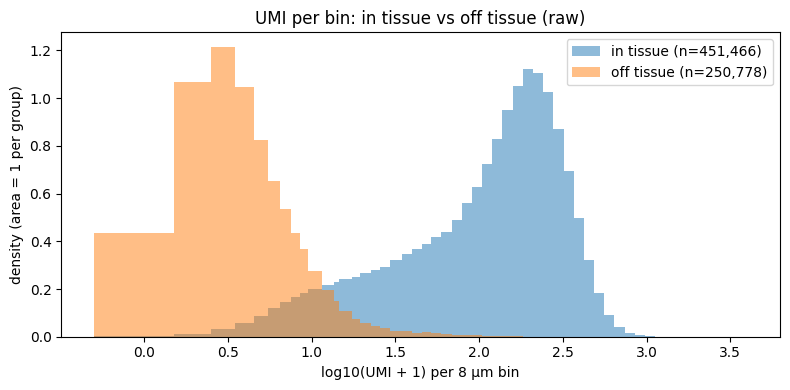

In [ ]:
# Block 10b — Overlaid UMI histograms: in-tissue vs off-tissue bins (raw, 8 µm)
import numpy as np, matplotlib.pyplot as plt

edges = np.log10(np.r_[0.5, np.unique(np.round(np.geomspace(1, 4000, 60))) + 0.5])   # edges between integers
fig, ax = plt.subplots(figsize=(8, 4))
for flag, label in [(1, 'in tissue'), (0, 'off tissue')]:
    v = np.log10(raw.obs.loc[raw.obs['in_tissue'] == flag, 'umi'] + 1)
    ax.hist(v, bins=edges, density=True, alpha=0.5, label=f'{label} (n={len(v):,})')
ax.set(xlabel='log10(UMI + 1) per 8 µm bin', ylabel='density (area = 1 per group)',
       title='UMI per bin: in tissue vs off tissue (raw)')
ax.legend(); plt.tight_layout()
plt.savefig(WORK / 'umi_in_vs_off_8um.png', dpi=120); plt.show()

### Blok 10b notları: doku içi ve dışı UMI dağılımları (üst üste)
- Aralık sınırlarını tam sayıların ortasına koyunca 9b'deki diş diş görüntü kayboldu; o dikenler gerçekten görüntüleme kaynaklıymış.
- **Doku dışı:** Neredeyse hepsi 0–9 UMI'de, tepe 1–2 UMI civarında. En soldaki alçak ve geniş çubuk 0 UMI (%20,8). Alçak çünkü density grafiğinde payı çubuğun alanı veriyor, yüksekliği değil (%20,8 ÷ 0,48 ≈ 0,43). İnce bir kuyruk ~100 UMI'ye kadar uzanıyor.
- **Doku içi:** Tepe ~200 UMI'de. Solda ≈10–100 UMI arasında uzun, yavaş yükselen bir rampa var; ayrı bir tepe değil, geniş bir düşük sayımlı grup.
- **İki eğri ~10 UMI'de kesişiyor ve ≈4–30 UMI arasında örtüşüyor.** Doku içindeki 10'dan az UMI'li bin'ler (%6,6) sayımca doku dışına benziyor. Bunlar fakir doku bölgeleri, kenar bin'leri ya da maske hataları olabilir; yalnızca sayıma bakarak ayıramam, haritada göreceğim.
- Beklentilerimin hepsi tuttu: iki tepe, sol omuz, örtüşme ve doku dışı ince kuyruk.

In [ ]:
# Block 11a — Prepare the map: hires H&E image + bin values as 838 x 838 grids
import numpy as np
from PIL import Image
assert 'scalefactors' in raw.uns, 'run Block 8b first (scale factors)'

img = np.array(Image.open(S8 / 'spatial' / 'tissue_hires_image.png'))
s = raw.uns['scalefactors']['tissue_hires_scalef']            # full-res pixel -> hires pixel
g = raw.obs.sort_values(['array_row', 'array_col'])
shape = (g['array_row'].nunique(), g['array_col'].nunique())
grid = lambda col: g[col].to_numpy().reshape(shape)            # one value per bin, laid out as the slide grid
X, Y = grid('pxl_col_in_fullres') * s, grid('pxl_row_in_fullres') * s
M, U = grid('in_tissue'), np.log10(grid('umi') + 1)

print('image:', img.shape, '| hires scale:', s, '| grid:', shape)
print(f'grid in image pixels: x {X.min():.0f}-{X.max():.0f}, y {Y.min():.0f}-{Y.max():.0f}')
print('grid inside image:', X.min() >= 0 and Y.min() >= 0 and X.max() <= img.shape[1] and Y.max() <= img.shape[0])

image: (3818, 6000, 3) | hires scale: 0.071874365 | grid: (838, 838)
grid in image pixels: x 85-1844, y 404-2164
grid inside image: True


### Blok 11a notları: harita hazırlığı
- hires H&E görüntüsü 3.818 × 6.000 piksel, 3 renk kanalı (RGB). Bir hires pikseli ≈ 3,8 µm; görüntünün tamamı yaklaşık 22,8 × 14,5 mm'lik bir alanı gösteriyor.
- 838 × 838'lik ızgara görüntünün yalnızca bir bölümünü kaplıyor: x 85–1.844, y 404–2.164 piksel. Bu ≈ 6,7 × 6,7 mm ediyor, ızgaranın gerçek boyutuyla aynı. Izgaranın tamamı görüntünün içinde.
- H&E, ölçülen alandan çok daha büyük bir alanı gösteriyor. Izgaranın dışındaki doku ölçülmemiş doku demek; haritada ızgara sınırını mutlaka çizeceğim.
- Izgaranın 0. satırı görüntüde en altta (y ≈ 2.164), 0. sütunu en solda; ızgaranın satırları görüntüde aşağıdan yukarı sayılıyor. Çizimlerde her zaman piksel koordinatlarını kullanacağım.

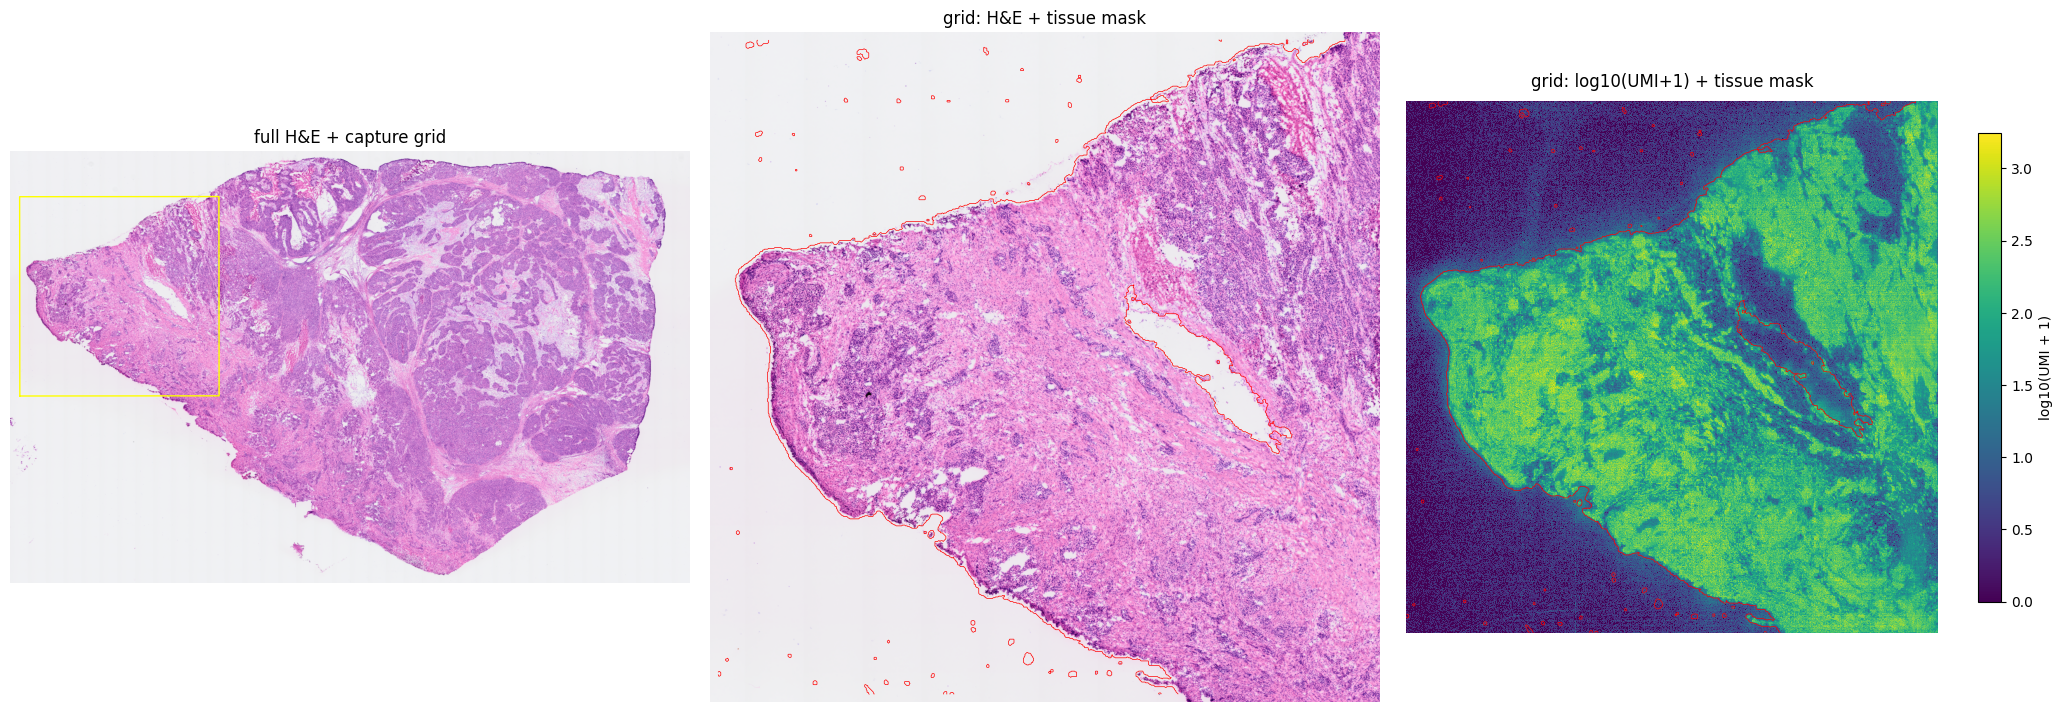

In [ ]:
# Block 11b — Maps: full H&E + grid outline | grid: H&E + tissue mask | grid: log UMI + tissue mask
import numpy as np, matplotlib.pyplot as plt

edge = lambda A: np.r_[A[0, :], A[:, -1], A[-1, ::-1], A[::-1, 0]]     # outline of the grid
fig, ax = plt.subplots(1, 3, figsize=(21, 7))
ax[0].imshow(img); ax[0].plot(edge(X), edge(Y), color='yellow', lw=1)
ax[1].imshow(img)
mesh = ax[2].pcolormesh(X, Y, U, cmap='viridis', shading='nearest')
plt.colorbar(mesh, ax=ax[2], shrink=0.7, label='log10(UMI + 1)')
for a in ax[1:]:
    a.contour(X, Y, M, levels=[0.5], colors='red', linewidths=0.5)        # Space Ranger tissue mask
    a.set_xlim(X.min() - 20, X.max() + 20); a.set_ylim(Y.max() + 20, Y.min() - 20); a.set_aspect('equal')
for a, t in zip(ax, ['full H&E + capture grid', 'grid: H&E + tissue mask', 'grid: log10(UMI+1) + tissue mask']):
    a.set_title(t); a.axis('off')
plt.tight_layout(); plt.savefig(WORK / 'map_umi_mask_8um.png', dpi=150); plt.show()

### Blok 11b notları: haritalar
- **Ölçülen alan kesitin yalnızca sol ucu.** H&E'deki kesit çok büyük; sarı kare (ızgara) gözle dokunun kabaca beşte birini kapsıyor. 28,9 mm²'lik doku alanı yalnızca karenin içindeki kısım. Prob verisiyle karşılaştırırken yakalama alanlarının kesitin hangi bölgesine denk geldiğine bakmam gerek; yoksa 02'ye bölge farkı da karışır.
- **Maske dokunun dış kenarını iyi izliyor.** Dokunun içindeki uzun beyaz boşluğu da dışarıda bırakmış.
- **Boş camda çok sayıda küçük "doku" adacığı var** (küçük kırmızı halkalar). Toz, kir ya da kırıntı olabilir. 10'dan az UMI'li doku içi bin'lerin bir kısmı bunlar olabilir; 11c'de sayacağım.
- **Doku ızgaranın sağ ve alt kenarına kadar uzanıyor.** Kenar profilinde "doku kenarı" ile "ölçüm alanı kenarı" ayrılmalı.
- **Doku içinde UMI dokunun yapısına göre değişiyor.** Boşluğun çevresinde, maskedeki delikten daha geniş düşük sinyalli bir alan var.
- **Doku dışında kenardan dışarı doğru sönen bir parıltı var** (yayılmanın görünen izi). Uzak bölgeler en koyu, doku ile ızgara kenarları arasında kalan sol alt üçgen biraz daha açık. Doku dışı sinyal uzaklıkla değişiyor; uzunluğunu kenar profiliyle ölçeceğim.
- Görüntünün kumlu olması Poisson gürültüsü (~150 UMI'de ~%8).
- **Açık soru:** Sağ üst köşede ızgara kenarı boyunca daha koyu bir şerit var. Doku mu, ölçüm alanının kenar etkisi mi?

In [ ]:
# Block 11c — Tissue mask pieces: how many, how big, and are low-UMI in-tissue bins in small islands?
import numpy as np
from scipy import ndimage

lab, n = ndimage.label(M)                                  # connected pieces of the mask (4-neighbour)
sizes = np.bincount(lab.ravel())[1:]                       # bins per piece (label 0 = off tissue)
print(f'mask pieces: {n:,} | 5 largest: {np.sort(sizes)[::-1][:5]} | pieces < 100 bins: {(sizes < 100).sum():,}')

g['piece_size'] = np.r_[0, sizes][lab.ravel()]             # size of the piece each bin belongs to
t = g[g['in_tissue'] == 1]
small = t['piece_size'] < 100
print(t.groupby(np.where(small, 'small pieces (<100)', 'large pieces'))['umi']
       .describe(percentiles=[.5]).round(1))
low = t['umi'] < 10
print(f"\nlow (<10 UMI) in-tissue bins: {low.sum():,} | in small pieces: {(low & small).sum():,} "
      f"({(low & small).sum() / low.sum():.1%})")

mask pieces: 64 | 5 largest: [449948    151    116     90     69] | pieces < 100 bins: 61
                      count  mean   std  min  50%   max
large pieces        450,215 156.2 130.5    0  132 1,773
small pieces (<100)   1,251  11.7  33.4    0    2   277

low (<10 UMI) in-tissue bins: 29,863 | in small pieces: 1,074 (3.6%)


### Blok 11c notları: maskenin parçaları
- **Maske 64 parçadan oluşuyor:** ana doku 449.948 bin (doku içinin %99,7'si), iki orta boy parça (151 ve 116 bin, ~100 × 100 µm) ve 100 bin'den küçük 61 adacık (toplam 1.251 bin, ortalama ~35 × 35 µm).
- **Küçük adacıklar doku dışı gibi:** UMI ortancaları 2 (doku dışıyla aynı; ana dokuda 132). %86'sında 10'dan az UMI var. Büyük olasılıkla toz, kir ya da kırıntı; en büyük değer 277, aralarında birkaç gerçek kırıntı olabilir.
- **Hipotezim büyük ölçüde çürüdü:** 10'dan az UMI'li doku içi bin'lerin yalnızca %3,6'sı adacıklarda; %96'sı ana dokunun içinde. Düşük sayımlı bin'lerin çoğu ana dokudaki düşük sinyalli bölgeler.
- **Adacıklar doku içi istatistikleri neredeyse etkilemiyor** (ortalama 155,8'den 156,2'ye). Ama kenar profilinde "doku" olarak yalnızca ana parçayı (ya da belli bir boyutun üstündekileri) almalıyım; yoksa adacıkların çevresi yanlışlıkla "dokuya yakın" görünür.

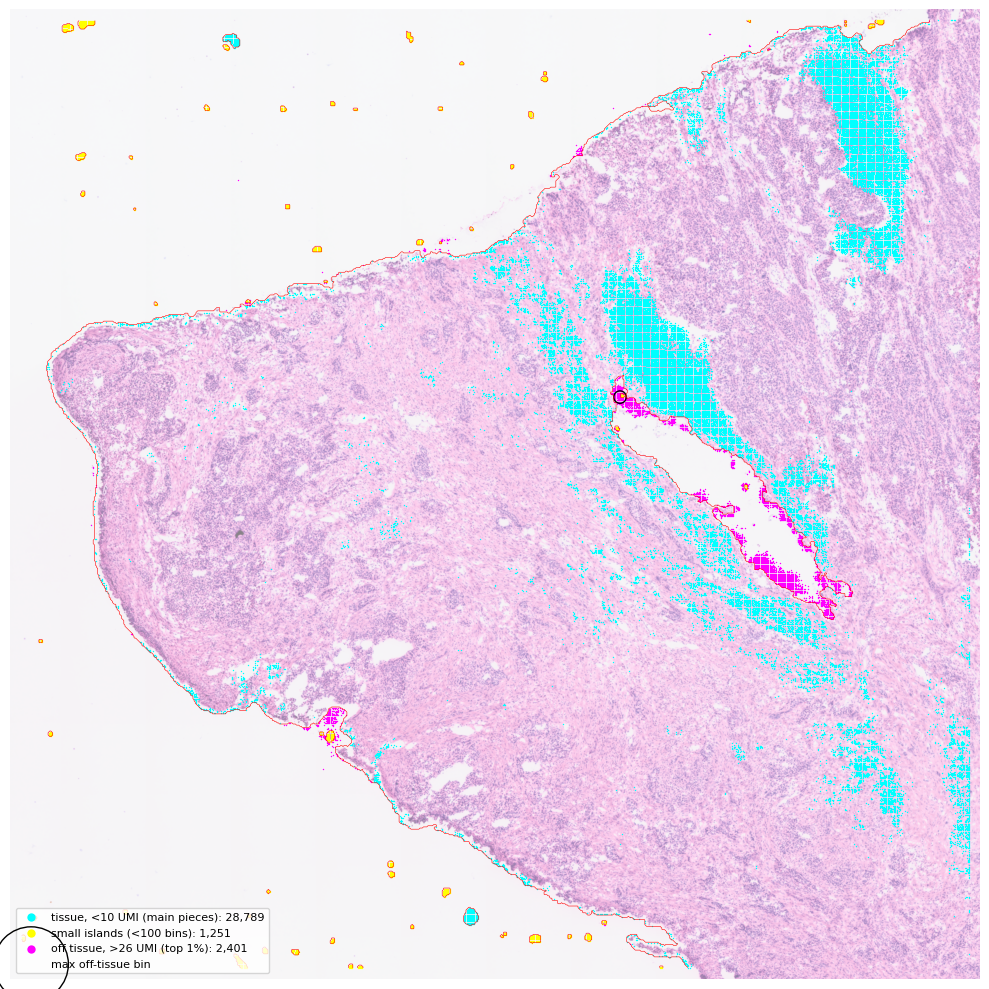

In [ ]:
# Block 11d — Where are they? low-UMI tissue bins, small islands, high-UMI off-tissue bins
import numpy as np, matplotlib.pyplot as plt

xy = lambda d: (d['pxl_col_in_fullres'] * s, d['pxl_row_in_fullres'] * s)   # full-res -> hires pixels
tis, off = g[g['in_tissue'] == 1], g[g['in_tissue'] == 0]
groups = {
    'tissue, <10 UMI (main pieces)': (tis[(tis['umi'] < 10) & (tis['piece_size'] >= 100)], 'cyan'),
    'small islands (<100 bins)':     (tis[tis['piece_size'] < 100], 'yellow'),
    'off tissue, >26 UMI (top 1%)':  (off[off['umi'] > 26], 'magenta'),
}
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img, alpha=0.5)
ax.contour(X, Y, M, levels=[0.5], colors='red', linewidths=0.4)
for label, (d, c) in groups.items():
    ax.scatter(*xy(d), s=1, c=c, linewidths=0, label=f'{label}: {len(d):,}')
ax.scatter(*xy(off.nlargest(1, 'umi')), s=80, facecolors='none', edgecolors='black', label='max off-tissue bin')
ax.set_xlim(X.min() - 20, X.max() + 20); ax.set_ylim(Y.max() + 20, Y.min() - 20); ax.axis('off')
ax.legend(loc='lower left', markerscale=6, fontsize=8)
plt.tight_layout(); plt.savefig(WORK / 'map_flagged_bins_8um.png', dpi=150); plt.show()

### Blok 11d notları: işaretli bin'ler nerede?
- **Ana dokuda 10'dan az UMI'li bin'ler (28.789) kümeler hâlinde, dağınık değil:**
  - sağ üstte büyük bir blok (H&E'de kan ya da fibrin olabilir, ya da yerel bir teknik sorun),
  - beyaz boşluğun çevresinde geniş bir şerit,
  - sağ altta bir yama ve ızgaranın sağ kenarı boyunca bir şerit,
  - dış kenar boyunca ince bir hat (kısmen dokuya değen bin'ler).

  Düşük sinyal bölgesel. Biyolojik mi teknik mi, H&E'ye yakından bakmadan karar veremem.
- **Küçük adacıklar** boş camdaki halkaların yerinde. 11c'deki iki "orta boy" parça (151 ve 116 bin) da düşük sayımlı çıktı; muhtemelen onlar da kir. Doğru ayrım: ana parça ve geri kalan her şey.
- **Yüksek sayımlı doku dışı bin'ler (2.401), beklediğim gibi dış kenarda değil, dokunun içindeki beyaz boşlukta.** Sol alt kenarda da bir küme var. Dış kenardaki parıltı 26 UMI'nin altında kalıyor.
  - Olası açıklama: Boşluktaki bin'ler her yandan dokuyla çevrili, bu yüzden birçok yönden sızıntı alıyor. Ya da boşlukta maskenin görmediği gevşek doku var.
  - Kenar profilinde iç boşluklar ile dış kenar ayrı ele alınmalı. Geometri sinyali değiştiriyor; organoidler arasındaki boşluklar için de önemli.
- **En yüksek sayımlı doku dışı bin (380 UMI)** boşluğun üst ucunda, dokunun kenarında.
- Camgöbeği bloklardaki ince beyaz ızgara çizgileri büyük olasılıkla çizim kaynaklı.

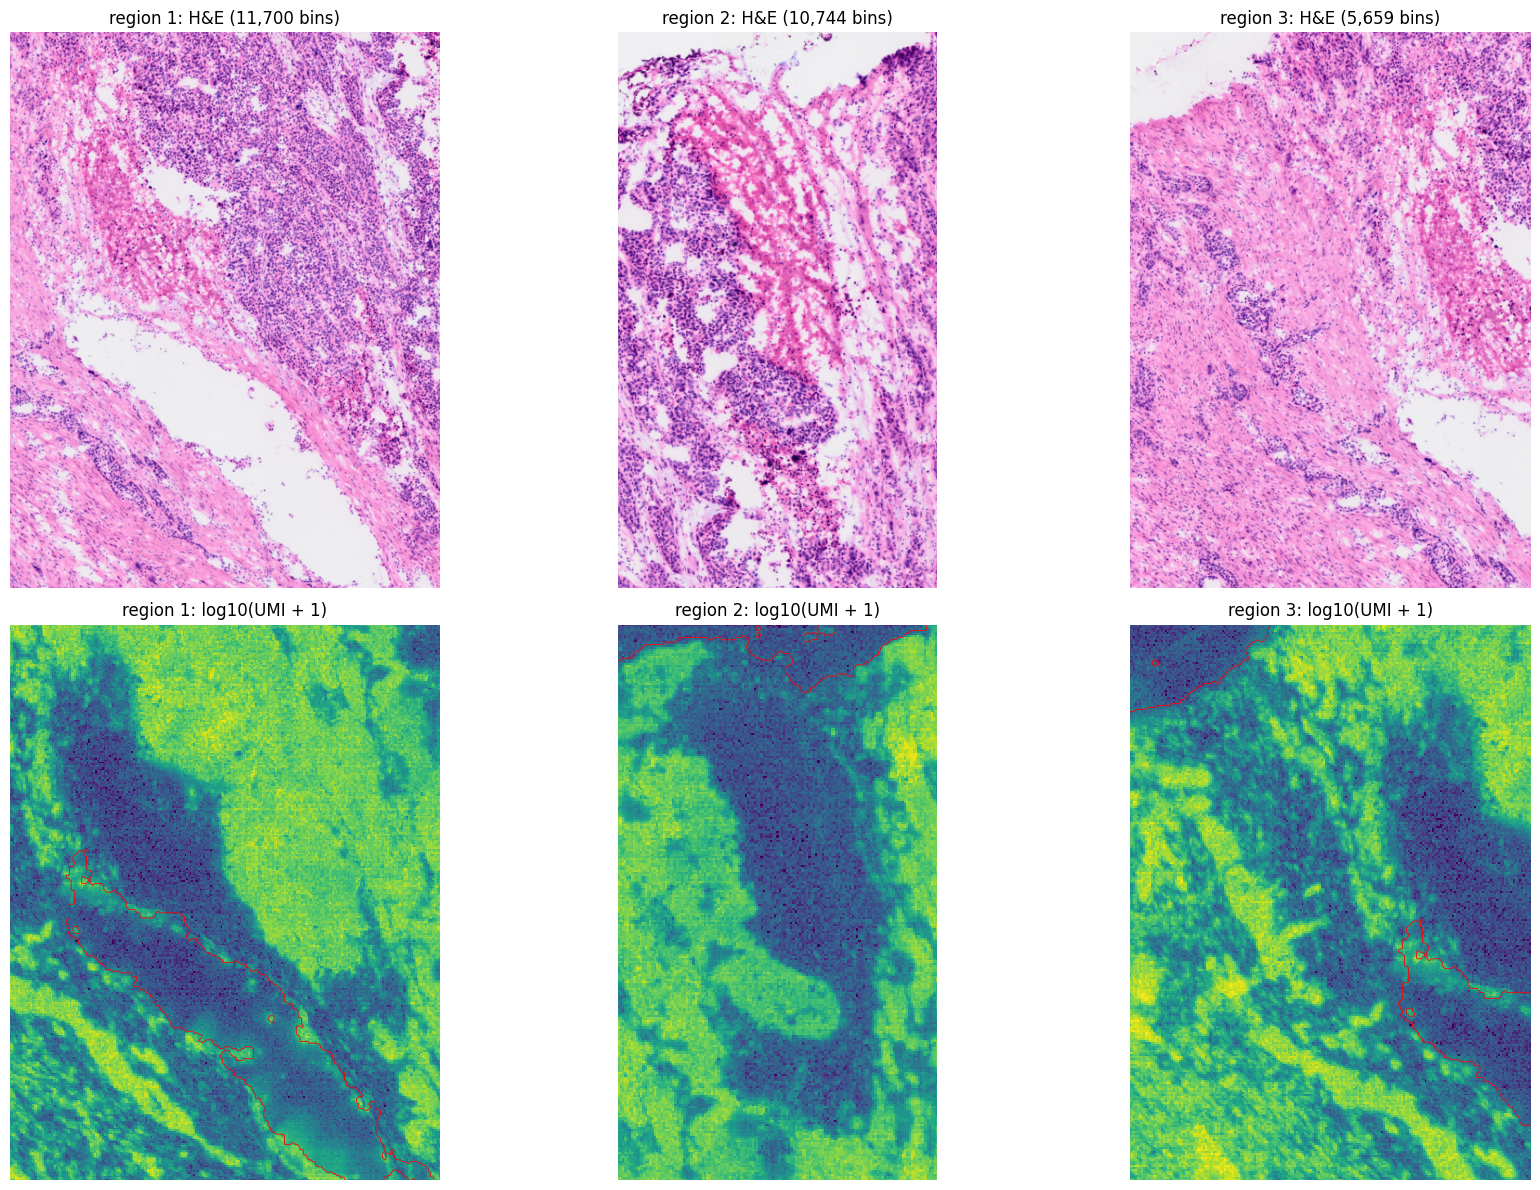

In [ ]:
# Block 11e — Zoom: H&E vs log UMI in the 3 largest low-UMI regions of the main tissue piece
import numpy as np, matplotlib.pyplot as plt
from scipy import ndimage

L = (lab == sizes.argmax() + 1) & (grid('umi') < 10)             # low-UMI bins inside the main piece
reg, _ = ndimage.label(ndimage.binary_closing(L, iterations=3))    # merge nearby low bins into regions
top3 = np.argsort(np.bincount(reg.ravel())[1:])[::-1][:3] + 1      # labels of the 3 largest regions
fig, ax = plt.subplots(2, 3, figsize=(18, 12))
for j, r in enumerate(top3):
    rows, cols = ndimage.find_objects(reg)[r - 1]                  # bounding box (grid rows, cols)
    rr = slice(max(rows.start - 20, 0), rows.stop + 20)            # + 20 bins (160 µm) margin
    cc = slice(max(cols.start - 20, 0), cols.stop + 20)
    x, y = X[rr, cc], Y[rr, cc]
    ax[0, j].imshow(img)
    ax[1, j].pcolormesh(x, y, U[rr, cc], cmap='viridis', shading='nearest', vmin=0, vmax=3)
    ax[1, j].contour(x, y, M[rr, cc], levels=[0.5], colors='red', linewidths=0.6)
    ax[0, j].set_title(f'region {j + 1}: H&E ({(reg == r).sum():,} bins)')
    ax[1, j].set_title(f'region {j + 1}: log10(UMI + 1)')
    for a in ax[:, j]:
        a.set_xlim(x.min(), x.max()); a.set_ylim(y.max(), y.min()); a.set_aspect('equal'); a.axis('off')
plt.tight_layout(); plt.savefig(WORK / 'zoom_low_umi_regions_8um.png', dpi=150); plt.show()

### Blok 11e notları: düşük sinyalli bölgelere yakından bakış
**Görselleri nasıl okudum:**
1. Aynı yeri iki panelde buldum. Eksenler aynı; beyaz boşluklar ve kırmızı çizgi (maskenin sınırı) referans noktası.
2. H&E: koyu mor noktalar çekirdek (hücreden zengin alan), pembe stroma, parlak pembe-kırmızı ve çekirdeksiz alan kan ya da fibrin olabilir, beyaz boşluk.
3. UMI: sarı-yeşil yüksek (log 2,5 ≈ 300 UMI), turkuaz orta (log 1,5 ≈ 30), koyu mavi-mor düşük (10 UMI'den az).
4. Mor alan parlak, çekirdeksiz alan koyu, beyaz boşluk maskenin dışındaysa biyoloji; hücreden zengin alan koyuysa teknik şüphe.
5. Koyu alanın sınırı H&E'deki bir yapıyı izliyorsa biyoloji; düz çizgi, dikdörtgen ya da ızgara kenarına paralel bir şerit ise teknik sorun.
Sınır: hires ~3,8 µm/piksel; doku düzeyini okuyabiliyorum, tek hücreyi değil.

**Bulgular:**
- Bölge 1 (11.700 bin, boşluğun çevresi) ve bölge 3 (5.659 bin): koyu alanlar pembe-kırmızı, çekirdeği az malzemeye ve boşlukların çevresine denk geliyor. Mor hücre kümeleri parlak.
- Bölge 2 (10.744 bin, sağ üst blok): ortadaki pembe-kırmızı, lifli alan büyük koyu bölgeyle örtüşüyor; iki yanındaki mor kümeler parlak.
- **Karar:** Düşük sinyal büyük olasılıkla biyolojik (az RNA içeren kan, fibrin ya da gevşek doku); teknik bir aktarma sorunu izlenimi yok. Bölgeleri bırakıyorum, not ediyorum. Malzemenin ne olduğunu kesin söylemek için tam çözünürlüklü görüntü ya da patolog gerekir.